# Promotion Dashboard (Khuyến mãi & Thanh toán)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv(r"E:\DATN\PRO2291_duantotnghiep1\data\raw\sales_06_FY2020-21.csv")

df.head()

C:\Users\truon\AppData\Local\Temp\ipykernel_17244\3499993284.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"E:\DATN\PRO2291_duantotnghiep1\data\raw\sales_06_FY2020-21.csv")


,order_id,order_date,status,item_id,sku,qty_ordered,price,value,discount_amount,total,...,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name,Discount_Percent
0,100354678,2020-10-01,received,574772.0,oasis_Oasis-064-36,21.0,89.9,1798.0,0.0,1798.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
1,100354678,2020-10-01,received,574774.0,Fantastic_FT-48,11.0,19.0,190.0,0.0,190.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
2,100354680,2020-10-01,complete,574777.0,mdeal_DMC-610-8,9.0,149.9,1199.2,0.0,1199.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
3,100354680,2020-10-01,complete,574779.0,oasis_Oasis-061-36,9.0,79.9,639.2,0.0,639.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
4,100367357,2020-11-13,received,595185.0,MEFNAR59C38B6CA08CD,2.0,99.9,99.9,0.0,99.9,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0


In [8]:
print(df.columns.tolist())

['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered', 'price', 'value', 'discount_amount', 'total', 'category', 'payment_method', 'bi_st', 'cust_id', 'year', 'month', 'ref_num', 'Name Prefix', 'First Name', 'Middle Initial', 'Last Name', 'Gender', 'age', 'full_name', 'E Mail', 'Customer Since', 'SSN', 'Phone No. ', 'Place Name', 'County', 'City', 'State', 'Zip', 'Region', 'User Name', 'Discount_Percent']


In [11]:
df.columns = df.columns.str.strip().str.lower()

In [9]:
# ======================================================
# KPI 1: MỨC GIẢM GIÁ TRUNG BÌNH
# ======================================================

avg_discount = df["Discount_Percent"].mean()

# ======================================================
# KPI 2: GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH (AOV)
# ======================================================

aov = (
    df.groupby("order_id")["total"]
      .sum()
      .mean()
)

# ======================================================
# KPI 3: TỔNG TIỀN GIẢM GIÁ
# ======================================================

total_discount = df["discount_amount"].sum()

# ======================================================
# KPI 4: TỶ LỆ ĐƠN HÀNG CÓ GIẢM GIÁ
# ======================================================

discount_order_rate = (
    (df["Discount_Percent"] > 0).sum()
    / len(df)
) * 100

# ======================================================
# HIỂN THỊ KẾT QUẢ KPI
# ======================================================

print(f"Average Discount: {avg_discount:.2f}%")
print(f"Average Order Value: {aov:.2f}")
print(f"Total Discount Amount: {total_discount:.2f}")
print(f"Discount Order Rate: {discount_order_rate:.2f}%")

Average Discount: 6.07%
Average Order Value: 1158.31
Total Discount Amount: 20058731.64
Discount Order Rate: 36.07%


# Discount Distribution

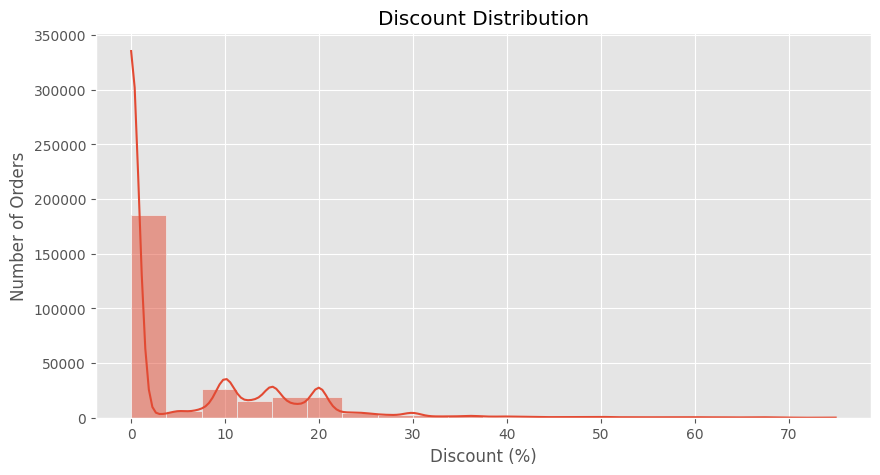

In [12]:
# =============================================
# BIỂU ĐỒ PHÂN BỐ MỨC GIẢM GIÁ
# =============================================

plt.figure(figsize=(10,5))

# Vẽ biểu đồ Histogram
# bins=20 chia dữ liệu thành 20 khoảng
# kde=True hiển thị đường phân bố

sns.histplot(
    data=df,
    x="discount_percent",
    bins=20,
    kde=True
)

# Tiêu đề biểu đồ
plt.title("Discount Distribution")

# Nhãn trục X
plt.xlabel("Discount (%)")

# Nhãn trục Y
plt.ylabel("Number of Orders")

# Hiển thị biểu đồ
plt.show()

In [13]:
# ==========================================
# CHIA NHÓM MỨC GIẢM GIÁ
# ==========================================

def discount_group(x):

    # Không giảm giá
    if x == 0:
        return "No Discount"

    # Giảm từ 1 đến 10%
    elif x <= 10:
        return "Low Discount"

    # Giảm từ 11 đến 30%
    elif x <= 30:
        return "Medium Discount"

    # Giảm trên 30%
    else:
        return "High Discount"

# Tạo cột mới discount_group
df["discount_group"] = df["discount_percent"].apply(discount_group)

# Tính doanh thu từng nhóm

In [14]:
# ==========================================
# TÍNH DOANH THU THEO NHÓM GIẢM GIÁ
# ==========================================

revenue_discount = (
    df.groupby("discount_group")["total"]
      .sum()
      .reset_index()
)

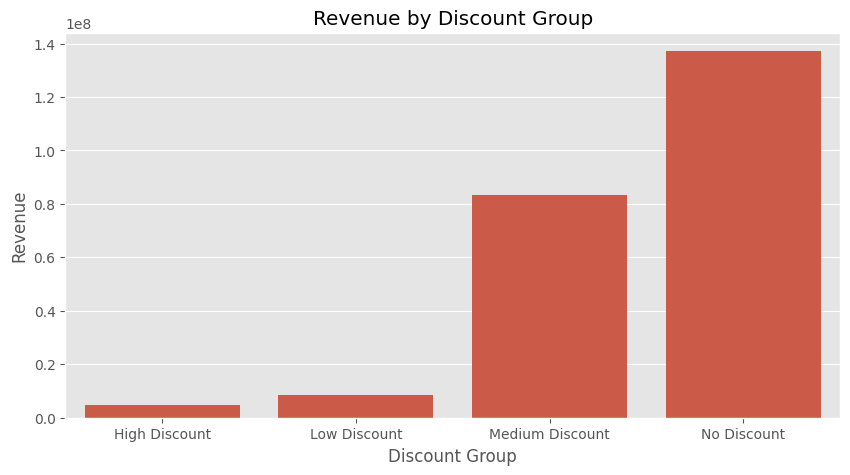

In [15]:
# ==========================================
# DOANH THU THEO NHÓM GIẢM GIÁ
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=revenue_discount,
    x="discount_group",
    y="total"
)

plt.title("Revenue by Discount Group")

plt.xlabel("Discount Group")

plt.ylabel("Revenue")

plt.show()

# Discount vs Revenue

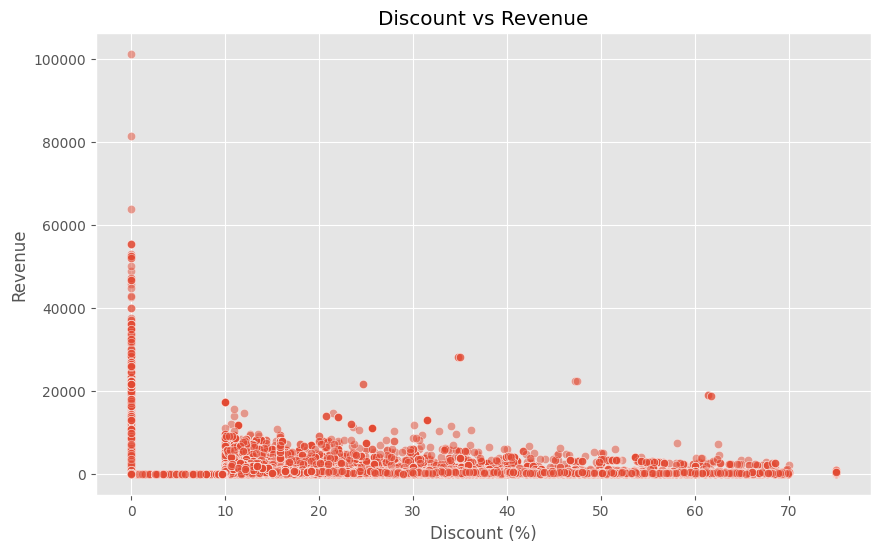

In [16]:
# ==========================================
# MỐI QUAN HỆ GIỮA GIẢM GIÁ VÀ DOANH THU
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="discount_percent",
    y="total",
    alpha=0.5
)

plt.title("Discount vs Revenue")

plt.xlabel("Discount (%)")

plt.ylabel("Revenue")

plt.show()

# Payment Method Distribution

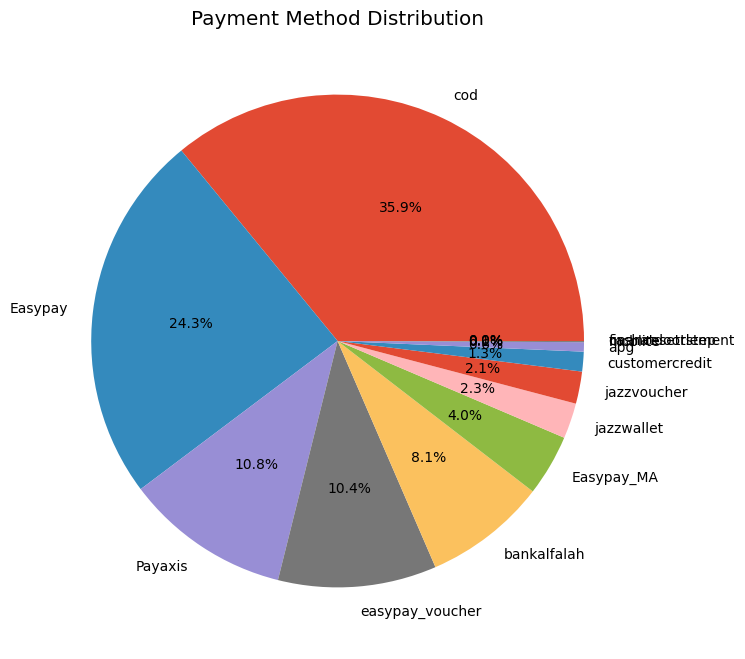

In [18]:
# ==========================================
# PHÂN BỐ PHƯƠNG THỨC THANH TOÁN
# ==========================================

payment_count = (
    df["payment_method"]
      .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    payment_count,
    labels=payment_count.index,
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")

plt.show()

# Revenue by Payment Method

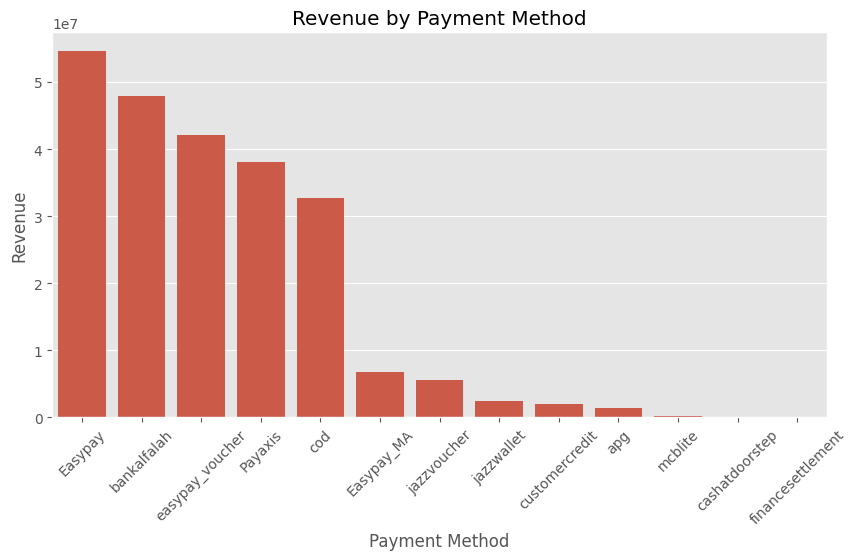

In [23]:
# ==========================================
# DOANH THU THEO PHƯƠNG THỨC THANH TOÁN
# ==========================================

payment_revenue = (
    df.groupby("payment_method")["total"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

plt.title("Revenue by Payment Method")

plt.xlabel("Payment Method")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# Average Discount by Category

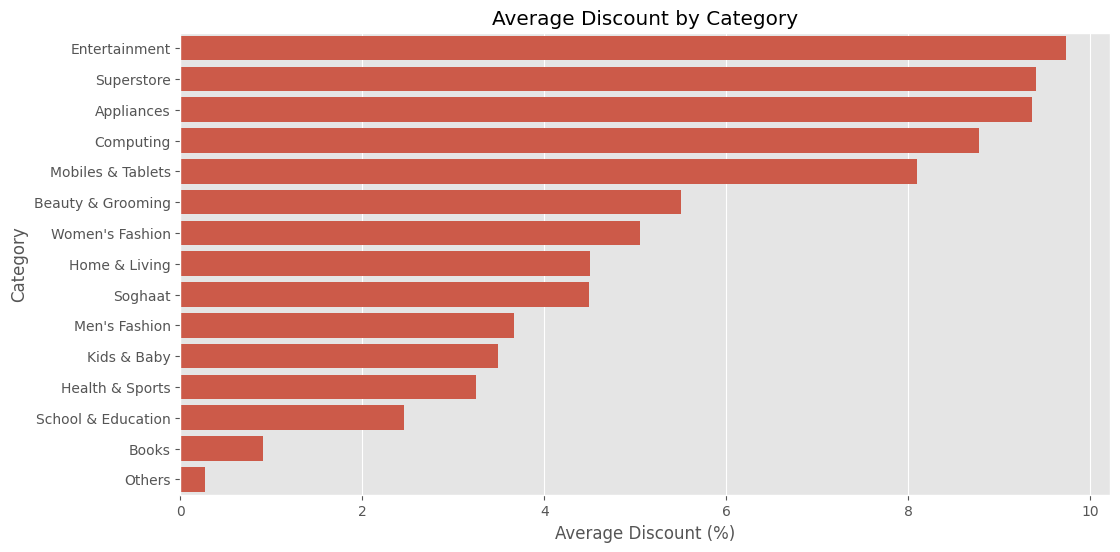

In [20]:
# ==========================================
# MỨC GIẢM GIÁ TRUNG BÌNH THEO DANH MỤC
# ==========================================

category_discount = (
    df.groupby("category")["discount_percent"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_discount.values,
    y=category_discount.index
)

plt.title("Average Discount by Category")

plt.xlabel("Average Discount (%)")

plt.ylabel("Category")

plt.show()

# Average Discount by Category

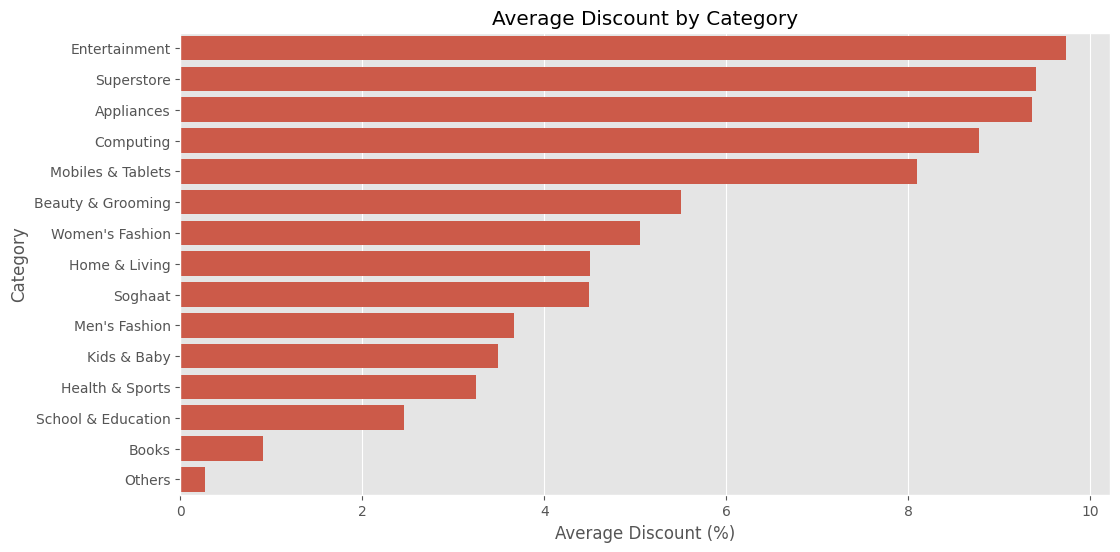

In [21]:
# ==========================================
# MỨC GIẢM GIÁ TRUNG BÌNH THEO DANH MỤC
# ==========================================

category_discount = (
    df.groupby("category")["discount_percent"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_discount.values,
    y=category_discount.index
)

plt.title("Average Discount by Category")

plt.xlabel("Average Discount (%)")

plt.ylabel("Category")

plt.show()

# Discount Effectiveness

In [22]:
# ==========================================
# SO SÁNH HIỆU QUẢ GIỮA ĐƠN HÀNG
# CÓ GIẢM GIÁ VÀ KHÔNG GIẢM GIÁ
# ==========================================

effectiveness = (
    df.groupby(df["discount_percent"] > 0)
      .agg(
          Revenue=("total","sum"),
          Orders=("order_id","nunique"),
          AOV=("total","mean")
      )
)

effectiveness.index = [
    "No Discount",
    "Discount"
]

print(effectiveness)

                  Revenue  Orders         AOV
No Discount  1.371792e+08  121970  749.261220
Discount     9.647095e+07   83454  933.836899
